<a href="https://colab.research.google.com/github/vikaspr042/Ml-Lab/blob/main/Banking_Vikas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset:

   Transaction_Amount Transaction_Time   Location Merchant_Category  \
0                5000          Morning    Chennai           Grocery   
1               12000            Night  Bangalore       Electronics   
2                3000        Afternoon  Hyderabad              Food   
3               45000            Night      Delhi           Jewelry   
4                7000          Evening     Mumbai            Travel   
5               15000          Morning    Chennai           Grocery   
6                2500            Night      Delhi              Food   
7               60000        Afternoon     Mumbai           Jewelry   
8               10000          Evening  Hyderabad            Travel   
9                8000          Morning  Bangalore       Electronics   

  Customer_Spending_Pattern Device_Information  Account_History  \
0                       Low             Mobile                2   
1                      High             Laptop                5  

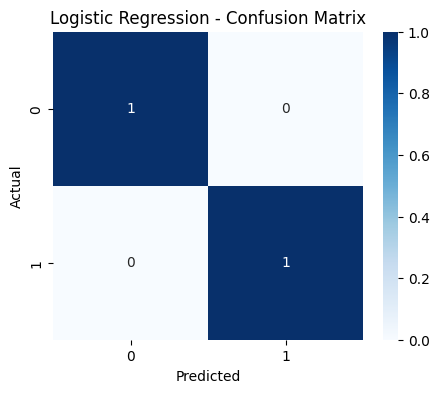


===== Decision Tree Model =====

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



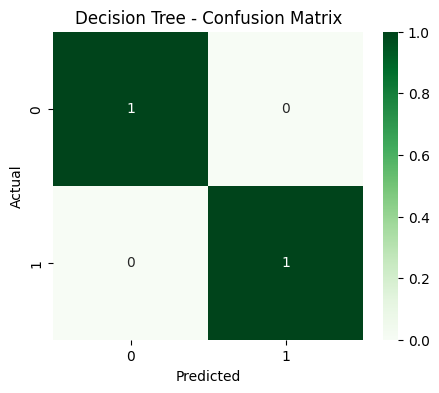

In [1]:
# 1. Logistic Regression
# 2. Decision Tree

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


data = {
    'Transaction_Amount': [5000, 12000, 3000, 45000, 7000, 15000, 2500, 60000, 10000, 8000],
    'Transaction_Time': ['Morning', 'Night', 'Afternoon', 'Night', 'Evening', 'Morning', 'Night', 'Afternoon', 'Evening', 'Morning'],
    'Location': ['Chennai', 'Bangalore', 'Hyderabad', 'Delhi', 'Mumbai', 'Chennai', 'Delhi', 'Mumbai', 'Hyderabad', 'Bangalore'],
    'Merchant_Category': ['Grocery', 'Electronics', 'Food', 'Jewelry', 'Travel', 'Grocery', 'Food', 'Jewelry', 'Travel', 'Electronics'],
    'Customer_Spending_Pattern': ['Low', 'High', 'Medium', 'High', 'Medium', 'Low', 'Low', 'High', 'Medium', 'High'],
    'Device_Information': ['Mobile', 'Laptop', 'Mobile', 'Tablet', 'Laptop', 'Mobile', 'Tablet', 'Laptop', 'Mobile', 'Tablet'],
    'Account_History': [2, 5, 1, 8, 4, 3, 2, 10, 6, 5],
    'Transaction_Frequency': [5, 12, 3, 20, 8, 6, 2, 25, 10, 11],
    'Fraud_Status': ['Legitimate', 'Fraudulent', 'Legitimate', 'Fraudulent', 'Legitimate',
                     'Legitimate', 'Fraudulent', 'Fraudulent', 'Legitimate', 'Fraudulent']
}

df = pd.DataFrame(data)

print("Original Dataset:\n")
print(df)


imputer = SimpleImputer(strategy='most_frequent')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

print("\nEncoded Dataset:\n")
print(df)


X = df.drop("Fraud_Status", axis=1)
y = df["Fraud_Status"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# MODEL 1: LOGISTIC REGRESSION


print("\n===== Logistic Regression Model =====\n")

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# MODEL 2: DECISION TREE

print("\n===== Decision Tree Model =====\n")

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

